In [191]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import numpy as np
from numpy import linalg as LA

# Task 1 Implement Logistic Regression

In [7]:
# Prediction function
def predict(Xi, W, b):
    z = np.dot(Xi, W) + b
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

In [8]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # TODO: This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            if iteration % (5*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b

# Task 2 Implement Logistic Regression

- Read both files
- Split train(70), test(15), validation(15)
- Train logistic regressor and check performance
- Scatter plot of results

In [9]:
# Reading data function
def read_data(file_path):
    df = pd.read_csv(file_path)
    y = df['Class'].values   # Labels
    X = df.drop('Class', axis=1).values  # Features
    return X, y

In [10]:
def split_data(X, y, train_ratio=0.7, test_ratio=0.15, validation_ratio=0.15, random_state=1):
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    X_train, X_test_pre, y_train, y_test_pre = sklearn.model_selection.train_test_split(
    X, y, train_size=train_ratio, random_state=random_state)
    
    X_test, X_val, y_test, y_val = sklearn.model_selection.train_test_split(
    X_test_pre, y_test_pre, train_size=test_ratio/(test_ratio + validation_ratio), random_state=random_state)
    
    return X_train, y_train, X_test, y_test, X_val, y_val

## Blobs 600 dataset

In [11]:
file_path = 'data/blobs600.csv'
# file_path = 'data/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y_train, W, b, alpha=0.01, max_iters=10000, threshold=1e-4)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 5  Cost: [14.49132644]  Previous Cost: [18.7976724]
Difference in cost function: [4.30634596]
Epoch: 10  Cost: [13.19302473]  Previous Cost: [11.00449937]
Difference in cost function: [2.18852537]
Epoch: 15  Cost: [8.43640352]  Previous Cost: [6.72937081]
Difference in cost function: [1.7070327]
Epoch: 20  Cost: [4.74670646]  Previous Cost: [5.87995414]
Difference in cost function: [1.13324767]


In [12]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.9976190476190476
Test Accuracy: 0.9888888888888889
Validation Accuracy: 0.9888888888888889


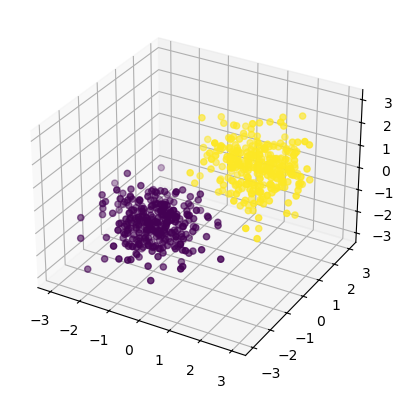

In [13]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[:, 0], X_all[:, 1], X_all[:, 2], c=y_pred_all)

## Circles 500 dataset

In [14]:
# file_path = 'data/blobs600.csv'
file_path = 'data/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y, W, b, alpha=1e-4, max_iters=10000, threshold=1e-6)
print("Trained Weights:", W_trained)
print("Trained Bias:", b_trained)

Epoch: 5  Cost: [242.76672586]  Previous Cost: [242.75791476]
Difference in cost function: [0.0088111]
Epoch: 10  Cost: [242.73321486]  Previous Cost: [242.72339249]
Difference in cost function: [0.00982237]
Epoch: 15  Cost: [242.66679956]  Previous Cost: [242.74261753]
Difference in cost function: [0.07581797]
Epoch: 20  Cost: [242.59438376]  Previous Cost: [242.57949554]
Difference in cost function: [0.01488822]
Epoch: 25  Cost: [242.53320083]  Previous Cost: [242.56578993]
Difference in cost function: [0.0325891]
Trained Weights: [0.01119526 0.00745474]
Trained Bias: [0.00265608]


In [15]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.5257142857142857
Test Accuracy: 0.64
Validation Accuracy: 0.5066666666666667


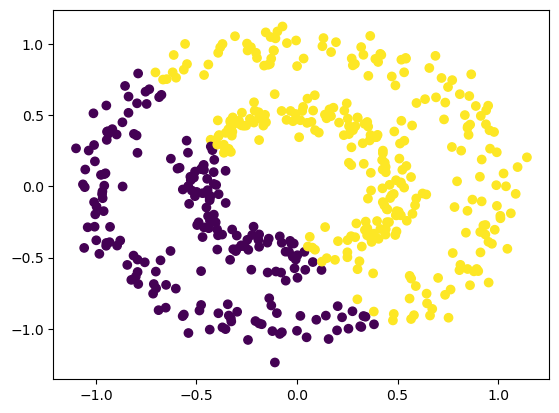

In [16]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

# Task 3: Implement and Test a Shallow Neural Network

- 1 hidden layer
- 1 output node
- Support different number of inputs and different number of nodes in the hidden layer

- Test previous datasets with different number of nodes in the hidden layer
- Measure performance

In [17]:
def parameter_initialization(X, neurons_hidden_layer):
    np.random.seed(3301)
    W1 = np.random.normal(0,0.01,size=(neurons_hidden_layer,X.shape[1]))
    W2 = np.random.normal(0,0.01,size=(1,neurons_hidden_layer))
    W = [W1, W2]

    b1 = np.random.normal(0,0.01,size=(neurons_hidden_layer))
    b2 = np.random.normal(0,0.01,size=(1))
    b = [b1, b2]
    
    # https://numpy.org/devdocs/reference/generated/numpy.zeros.html
    z1 = np.zeros(shape=(neurons_hidden_layer))
    z2 = np.zeros(shape=(1))
    z = [z1, z2]
    a0 = np.zeros(shape=(X.shape[1]))
    a1 = np.zeros(shape=(neurons_hidden_layer))
    a2 = np.zeros(shape=(1))
    a = [a0, a1, a2]

    return W, b, z, a

In [18]:
# Forward propagation function
def forward_propagation(Xi, W, b, z, a):
   # X[observation][feature] 
   # W[layer][destination_node][source_node]
   # b[layer][destination_node]
   # z[layer][destination_node]
   # a[layer][destination_node]
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(1, 3):
      for destination_node in range(1, len(z[layer-1])+1):
         # Linear transformation 
         z[layer-1][destination_node-1] = np.dot(a[layer-1], W[layer-1][destination_node-1]) + b[layer-1][destination_node-1]
         # Activation function (Using logistic function)
         a[layer][destination_node-1] = 1 / (1 + np.exp(-z[layer-1][destination_node-1]))

   y_hat = a[layer][destination_node-1] # Output of the last layer is the prediction
   return y_hat, a, z

In [19]:
# Return only the prediction
def predict(X, W, b, z, a):
    y_hats = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_propagation(Xi, W, b, z, a)
        y_hats[i] = y_hat
    return y_hats

In [20]:
# Backpropagation and gradient descent function
def gradient_descent_t3(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0: # 1 Epoch finished
            if iteration % (100*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b, a, z  

## Circles 500 dataset

In [21]:
# file_path = 'data/blobs600.csv'
file_path = 'data/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 4
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, alpha=1e-2, max_iters=1e6, threshold=1e-4, neurons_hidden_layer=neurons_hidden_layer)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 100  Cost: 243.43300893775637  Previous Cost: 243.32894502636785
Difference in cost function: 0.104063911388522
Epoch: 200  Cost: 243.11308456802487  Previous Cost: 242.19863779786633
Difference in cost function: 0.9144467701585484
Epoch: 300  Cost: 242.8405251307001  Previous Cost: 243.65855892873813
Difference in cost function: 0.8180337980380443
Epoch: 400  Cost: 243.60241360949834  Previous Cost: 242.92529696812105
Difference in cost function: 0.677116641377296
Epoch: 500  Cost: 242.0887869031901  Previous Cost: 243.4886048567379
Difference in cost function: 1.399817953547796
Epoch: 600  Cost: 243.2088718308192  Previous Cost: 242.6221095422865
Difference in cost function: 0.5867622885326966
Epoch: 700  Cost: 242.638356195458  Previous Cost: 243.25293057537226
Difference in cost function: 0.6145743799142735
Epoch: 800  Cost: 243.5253895188107  Previous Cost: 242.07141926044835
Difference in cost function: 1.4539702583623466
Epoch: 900  Cost: 242.90285510522543  Previous Cost

In [22]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [23]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

Train Accuracy: 0.9914285714285714
Test Accuracy: 1.0
Validation Accuracy: 1.0


- It works with at least 3 neurons, high amount of iterations (100k or more) and learning rate of 1e-1

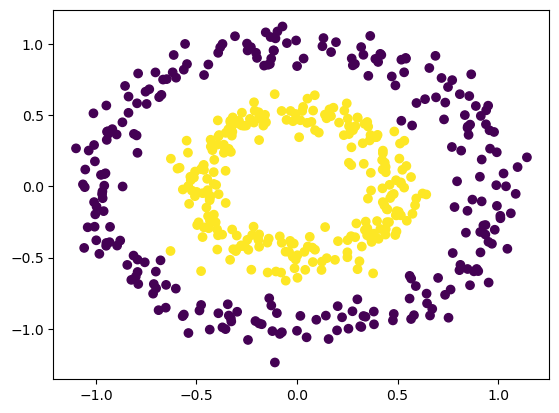

In [24]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

In [25]:
# neurons_hidden_layer = 5
# alpha = 0.01


# N = X.shape[0]
# stopping = False
# J_running = 0
# J_running_prev = 0
# iteration = 0
# # Initialize delta parameters for gradient descent
# delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
# delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
# delta_W = [delta_W1, delta_W2]

# delta_b1 = np.zeros(shape=(neurons_hidden_layer))
# delta_b2 = np.zeros(shape=(1))
# delta_b = [delta_b1, delta_b2]

# delta_z1 = np.zeros(shape=(neurons_hidden_layer))
# delta_z2 = np.zeros(shape=(1))
# delta_z = [delta_z1, delta_z2]


# # while not stopping:

# # Randomly select one data point #Sample size = 1       
# i_random = np.random.randint(0, high=N)
# y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
# J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))

# # Backpropagation step
# error = y_hat - y[i_random] 
# for layer in range(len(W), 0, -1):
#     print("Layer:", layer)
#     # Output layer gradients
#     if layer == len(W):
#         delta_z[layer-1] = error
#         delta_W[layer-1] = error * a[layer-1]
#         delta_b[layer-1] = error
#     # Hidden layer gradients
#     else:
#         # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
#         delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * delta_W[layer]
#         # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
#         delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
#         delta_b[layer-1] = delta_z[layer-1]

# # Update parameters step
# for layer in range(1, len(W)+1):
#     print("Layer:", layer)
#     W[layer-1] -= alpha * delta_W[layer-1]
#     b[layer-1] -= alpha * delta_b[layer-1]

# Task 4: Tackle a Challenging Task

- Read image dataset
- Filter two letters (C,F)
- Reshape images (flatten it)
- Train 1 hidden layer neural network
- Check accuracy
- Plot training curve


In [26]:
# Reading images
data = np.load("data/emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [27]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


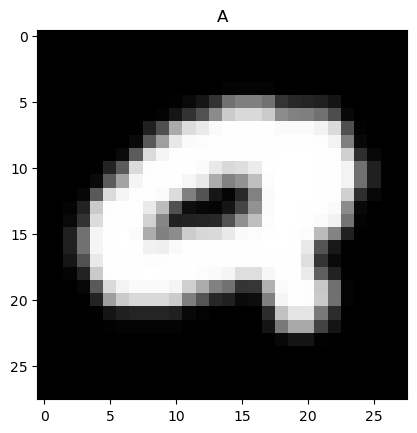

In [28]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))  
plt.show()

In [29]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

#plt.figure(figsize=(12, 6))

# for i, cls in enumerate(classes):
#     # Find first index of this class
#     idx = np.where(y_data == cls)[0][n]
    
#     plt.subplot(4, 7, i + 1)
#     plt.imshow(x_data[idx].squeeze(), cmap="gray")
#     plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
#     plt.axis("off")

#plt.tight_layout()
#plt.show()

In [30]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 3   # example
c2 = 6  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

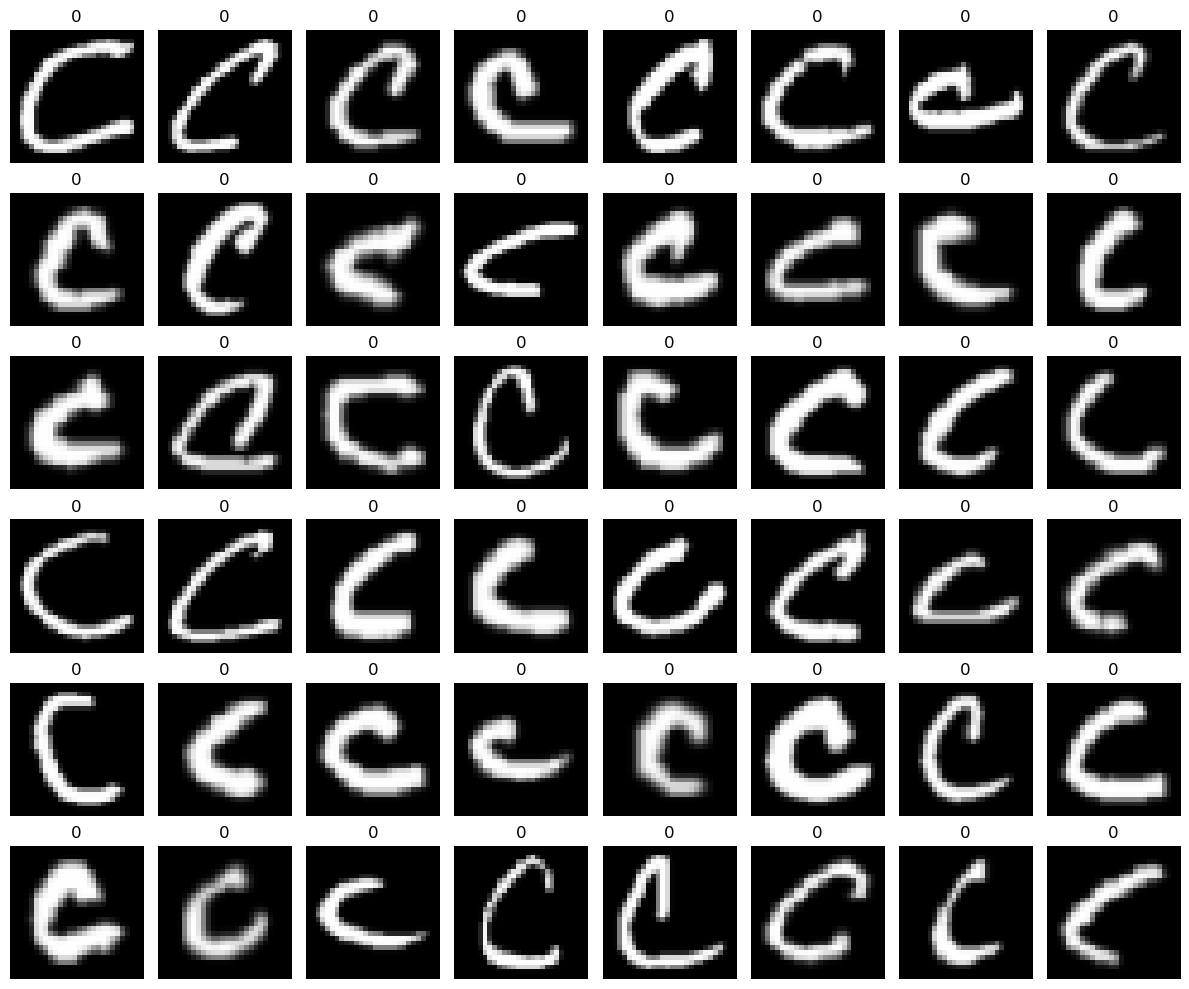

In [31]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

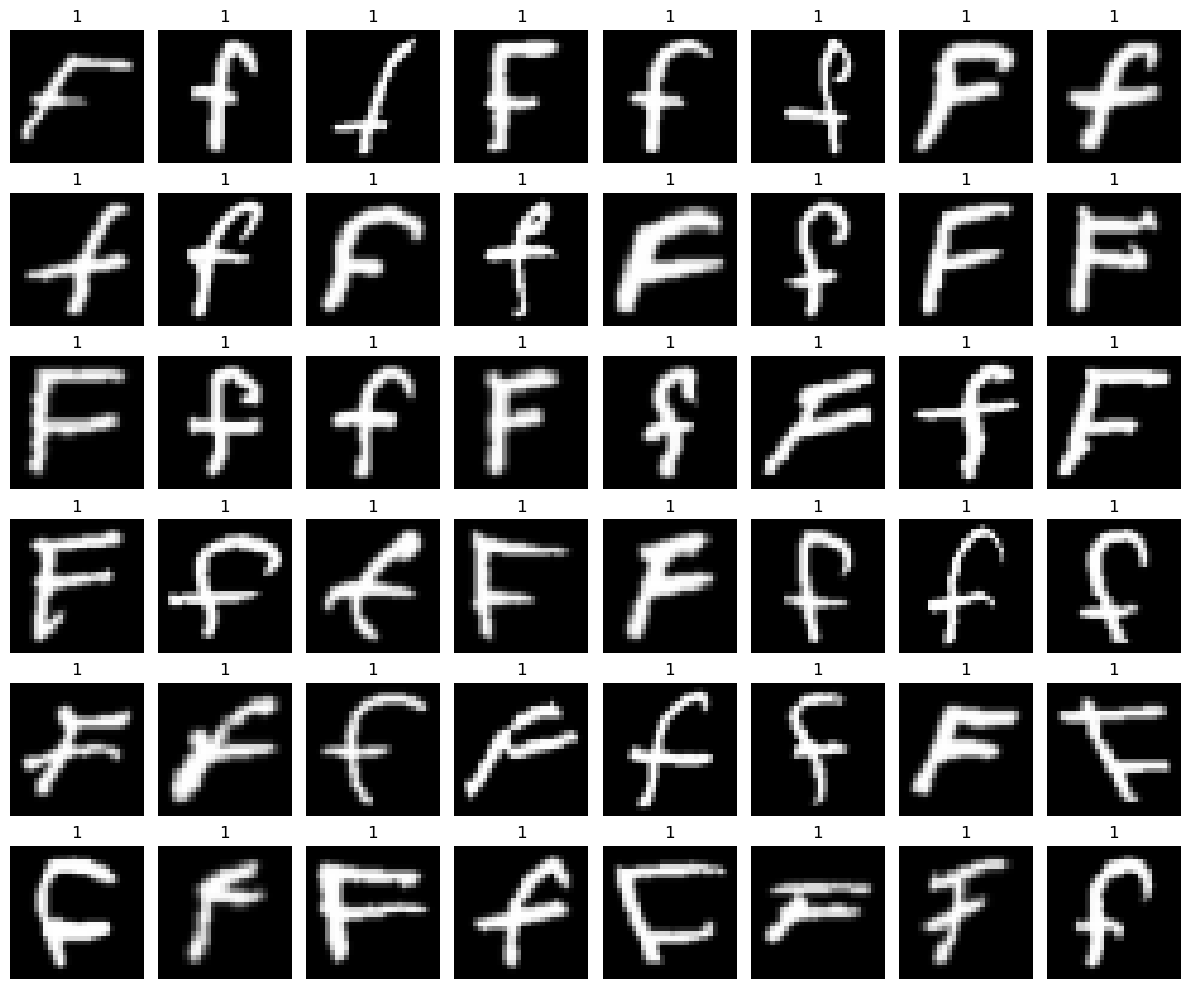

In [32]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

In [123]:
# Flatten the images
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 1
W, b, z, a = parameter_initialization(x_flat, neurons_hidden_layer=neurons_hidden_layer)
# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, alpha=1e-1, max_iters=100, threshold=1e-4, neurons_hidden_layer=neurons_hidden_layer)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

In [190]:
W

[array([[-0.00563357, -0.02073575, -0.00185757, ..., -0.00032726,
          0.01291238, -0.00905831],
        [-0.00765353, -0.01432738, -0.01057252, ..., -0.01253581,
         -0.01088463, -0.00298013],
        [-0.00512579, -0.00253016, -0.01851298, ..., -0.00482671,
          0.00511998, -0.00331237],
        ...,
        [ 0.00449218, -0.0075958 , -0.00178605, ...,  0.01193283,
          0.01511507,  0.00034721],
        [-0.00570631,  0.00073366, -0.00543886, ...,  0.0155612 ,
          0.0056308 , -0.01503282],
        [-0.00373964, -0.00654749, -0.00013769, ..., -0.00183732,
         -0.01190484,  0.00090578]], shape=(1024, 784)),
 array([[ 0.00998982, -0.00445172,  0.00825492, ...,  0.01904342,
          0.00427437, -0.0141692 ],
        [-0.00798677, -0.00584844, -0.01194946, ..., -0.00020217,
         -0.0030688 ,  0.01410857],
        [-0.02392155,  0.00310232, -0.01017143, ...,  0.00322089,
          0.00437471,  0.00588459],
        ...,
        [ 0.01503955, -0.01564924, 

In [34]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [35]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

#TODO: Check why it is having good performance with just one neuron
#TODO: Training curve

Train Accuracy: 0.946969696969697
Test Accuracy: 0.9404040404040404
Validation Accuracy: 0.9484848484848485


In [36]:
y_pred_val

array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,

In [37]:
y_val

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,

# Task 5: Deep Learning enhancements

In [26]:
# Reading images
data = np.load("data/emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [263]:
# hidden_neurons_per_layer = [3,4,5,6,7,8,9,10]
# each position in the array is the hidden layer and the value is the number of neurons in that layer
def robust_parameter_initialization(X, hidden_neurons_per_layer): #3,4,5,6,7,8,9,10]
    W = []
    b = []
    z = []
    a = []
    flW = []
    np.random.seed(3301)

    a.append(np.zeros(shape=(X.shape[1]))) # a0
    for i, num_neurons in enumerate(hidden_neurons_per_layer):
        if i == 0:
            prev_layer_neurons = X.shape[1]
        else:
            prev_layer_neurons = hidden_neurons_per_layer[i-1]
        # Create weight matrix for the current layer
        W_aux = np.random.normal(0,0.01,size=(num_neurons,prev_layer_neurons))
        W.append(W_aux)
        # Create bias vector for the current layer
        b_aux = np.random.normal(0,0.01,size=(num_neurons))
        b.append(b_aux)
        # Create z vector 
        z_aux = np.zeros(shape=(num_neurons))
        z.append(z_aux)
        # Create activation vector a
        a_aux = np.zeros(shape=(num_neurons))
        a.append(a_aux)
        # print(i, num_neurons)

    W_aux_ll = np.random.normal(0,0.01,size=(1,num_neurons))
    W.append(W_aux_ll)
    b_aux_ll = np.random.normal(0,0.01,size=(1))
    b.append(b_aux_ll)
    z_aux_ll = np.zeros(shape=(1))
    z.append(z_aux_ll)
    a_aux_ll = np.zeros(shape=(1))
    a.append(a_aux_ll)

    flW = W[-1]
    
    return W, b, z, a, flW

In [235]:
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
hidden_neurons_per_layer = [512, 256, 128, 64, 32]
W, b, z, a, flW = robust_parameter_initialization(X_train, hidden_neurons_per_layer=hidden_neurons_per_layer)

In [237]:
# Forward propagation function
def forward_prop(Xi, W, b, z, a):
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(len(W)):
       # Linear transformation 
       z[layer] = np.dot(W[layer], a[layer]) + b[layer]
       # Activation function (Using logistic function)
       a[layer + 1] = 1 / (1 + np.exp(-z[layer]))

   y_hat = a[len(a) - 1][0] # Output of the last layer is the prediction
   return y_hat, a, z

In [238]:
def predict_DNN(X, W, b, z, a):
    y_hat_arr = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_prop(Xi, W, b, z, a)
        y_hat_arr[i] = y_hat
    return y_hat_arr

In [269]:
def gradient_descent_l2(X, y, W, b, a, z, flW, alpha, max_iters, threshold, penlambda, hidden_neurons_per_layer):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    l2w = LA.norm(flW, 2)
    
    # Initialize delta parameters for gradient descent
    for i in range(len(hidden_neurons_per_layer)):
        delta_W1 = np.zeros(shape=(hidden_neurons_per_layer[i],X.shape[1]))
        delta_W2 = np.zeros(shape=(1,hidden_neurons_per_layer[i]))
        delta_W = [delta_W1, delta_W2]
    
        delta_b1 = np.zeros(shape=(hidden_neurons_per_layer[i]))
        delta_b2 = np.zeros(shape=(1))
        delta_b = [delta_b1, delta_b2]
    
        delta_z1 = np.zeros(shape=(hidden_neurons_per_layer[i]))
        delta_z2 = np.zeros(shape=(1))
        delta_z = [delta_z1, delta_z2]
    
        while not stopping:
            # Randomly select one data point #Sample size = 1       
            i_random = np.random.randint(0, high=N)
            y_hat, a, z = forward_prop(X[i_random], W, b, z, a)
            J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat)) + ((penlambda / (2*N)) * (l2w ** 2))
            
            # Backpropagation step
            error = y_hat - y[i_random] 
            for layer in range(len(W), 0, -1):
                # Output layer gradients
                if layer == len(W):
                    delta_z[layer-1] = error
                    # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                    delta_W[layer-1] = error * a[layer-1].reshape(1, -1) + ((penlambda / N) * delta_W[layer-1])
                    delta_b[layer-1] = error
                # Hidden layer gradients
                else:
                    # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                    delta_z[layer-1] = (a[layer] * (1 - a[layer])) * delta_z[layer] * W[layer].reshape(-1)
                    # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                    delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1]) + ((penlambda / N) * delta_W[layer-1])
                    delta_b[layer-1] = delta_z[layer-1]
    
            # Update parameters step
            for layer in range(1, len(W)+1):
                W[layer-1] -= alpha * delta_W[layer-1]
                b[layer-1] -= alpha * delta_b[layer-1]
            
            # Check stopping criteria
            iteration += 1
            J_running += J_current
            if iteration >= max_iters:
                stopping = True
            if iteration % N == 0: # 1 Epoch finished
                if iteration % (100*N) == 0:
                    # print("Average cost function over epoch:", J_running / N)
                    print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                    print("Difference in cost function:", abs(J_running - J_running_prev))
                if abs(J_running - J_running_prev) < threshold:
                    stopping = True
                J_running_prev = J_running
                J_running = 0
        
    return W, b, a, z

In [270]:
x_flat = x_binary.reshape(x_binary.shape[0], -1)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(x_flat, y_binary)
# Initialize weights and bias
np.random.seed(3301)
hidden_neurons_per_layer = [1024, 256, 128, 64, 32]
W, b, z, a, flW = robust_parameter_initialization(X_train, hidden_neurons_per_layer=hidden_neurons_per_layer)

W_trained, b_trained, a_trained, z_trained = gradient_descent_l2(X_train, y_train, W, b, a, z, flW, alpha=1e-2, max_iters=1e6, threshold=1e-4, penlambda=0.1, hidden_neurons_per_layer=hidden_neurons_per_layer)

6


<class 'IndexError'>: list assignment index out of range

In [194]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)